# **Análises Complementares em Python **

---



## Considerando o comportamento de cadastros até setembro de 2026, quantos livros poderíamos esperar em outubro, novembro e dezembro?

Anotações

Prever - ExponentialSmoothing
- Temos uma sequencia temporal, a ordem mensal é importante.
* 'trend' = - add para considerar uma tendencia
* 'seasonal'=None - sem sazonalidade


**Essa analise tem finalidade demonstrativa e educacional. A base Excel utilizada é com dados fictícios, exceto os dados das escolas que são daddos abertos da Prefeitura de SP.**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Carregar os dados de livros
excel_path = 'Troca_Livro_SP_Dados_Analiticos.xlsx'
livros = pd.read_excel(excel_path, sheet_name='Livros') # lendo a aba especifica


# Exibição dos nomes das colunas

print(livros.columns)



Index(['id_livro', 'user_id', 'titulo', 'autor', 'editora', 'ano_edicao',
       'disciplina_area_genero', 'estado_conservacao', 'observacoes',
       'modalidade', 'status', 'codigo_escola', 'escola', 'bairro', 'distrito',
       'subprefeitura', 'data_cadastro'],
      dtype='object')


C:\Users\Tamires\AppData\Local\Temp\ipykernel_18956\1968851949.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  livros['AnoMes'] = livros['data_cadastro_dt'].dt.to_period('M') # M (MONTH)


Previsão para os próximos meses:
2026-10-01    31.266413
2026-11-01    34.223926
2026-12-01    37.181440
Freq: MS, dtype: float64


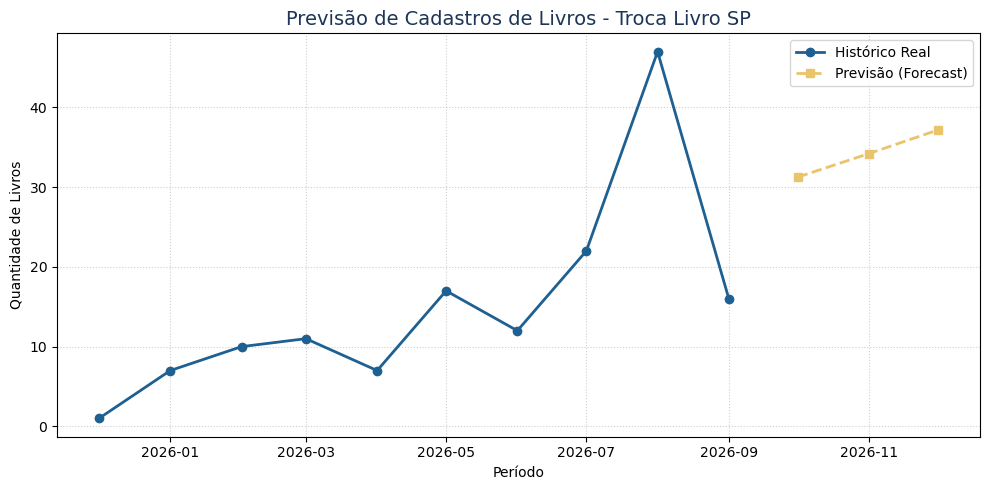

In [2]:

# Cada linha é um livro, entao transformamos as datas em serie mensal
# exemplo: em dezembro de 25 tivemos 3 registros.

livros['data_cadastro_dt'] = pd.to_datetime(livros['data_cadastro']) # Tratar como data
livros['AnoMes'] = livros['data_cadastro_dt'].dt.to_period('M') # M (MONTH)

# 2. Agrupar por mês e contar
serie = livros.groupby('AnoMes').size()
serie.index = serie.index.to_timestamp()  #datatimeIndex

# 3.Treinar o modelo - Ajustar o modelo de Holt-Winters (Suavização Exponencial com tendência)
# Temos meses (dez/2025 a set/2026)

model = ExponentialSmoothing(serie, trend='add', seasonal=None, initialization_method="estimated").fit()

# 4. Prever os próximos 3 meses (ex: Outubro, Novembro e Dezembro de 2026)
forecast = model.forecast(3)
print("Previsão para os próximos meses:")
print(forecast)

# 5. Plotar
plt.figure(figsize=(10, 5))
plt.plot(serie.index, serie.values, label='Histórico Real', marker='o', color='#1E6091', linewidth=2)
plt.plot(forecast.index, forecast.values, label='Previsão (Forecast)', marker='s', linestyle='--', color='#E9C46A', linewidth=2)
plt.title('Previsão de Cadastros de Livros - Troca Livro SP', fontsize=14, color='#1D3557')
plt.xlabel('Período')
plt.ylabel('Quantidade de Livros')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



# Criando um mapa
Meu primeiro mapa com python (Mapa coroplético)

Arquivo GeoJson - Dados abertos da Prefeitura de Sao Paulo

https://dadosabertos.urbis.prefeitura.sp.gov.br/sl/dataset/subprefeituras/resource/0e38226b-f623-444f-8069-9dd6c8a2a0af


In [3]:
import pandas as pd
import geopandas as gpd
import folium


# base

excel_path = 'Troca_Livro_SP_Dados_Analiticos.xlsx'
livros = pd.read_excel(excel_path, sheet_name='Livros')
escolas = pd.read_excel(excel_path, sheet_name='Escolas')


#Inspeçao das colunas do arquivo GeojSON

subprefeitura = gpd.read_file('subprefeituras.geojson')
subprefeitura.columns

Index(['id', 'nome', 'sigla', 'geometry'], dtype='object')

In [4]:
# Leitura do GeoJSON oficial, conferindo os dados
# nome e geometry -- ok

subprefeitura[['nome', 'geometry']].head(10)

,nome,geometry
0,Cidade Ademar,"POLYGON ((330535.931 7375754.983, 330224.762 7..."
1,M'Boi Mirim,"POLYGON ((316704.833 7378198.331, 316729.523 7..."
2,Mooca,"POLYGON ((341073.42 7391728.302, 341068.013 73..."
3,Ipiranga,"POLYGON ((333989.012 7387205.469, 333992.834 7..."
4,Lapa,"POLYGON ((323154.787 7394558.786, 323149.167 7..."
5,Jabaquara,"POLYGON ((331480.406 7384704.354, 331486.362 7..."
6,Guaianases,"MULTIPOLYGON (((357804.22 7394624.978, 357804...."
7,Santo Amaro,"POLYGON ((328661.077 7383182.44, 328660.807 73..."
8,Sapopemba,"POLYGON ((344268.066 7389087.384, 344266.579 7..."
9,São Miguel,"POLYGON ((353381.585 7401333.31, 353392.345 74..."


Ao decorrer dos códigos(mais pra frente), identifiquei que havia valores NAN, o que poderia ser normal, no entanto, matei a charada: notei que na base original(excel) os nomes das subprefeituras não tem acentuação (ex: Sao joao). E no arquivo geojson oficial da prefeitura tem.
E nessa parte a IA ajudou orientando a padronizar o texto, conforme segue o código abaixo.

In [5]:
#Padronização dos nomes

import unicodedata

def padronizar_texto (texto):
  if pd.isna(texto):
      return texto

  texto = str(texto).strip().lower()

  texto = unicodedata.normalize('NFKD', texto)
  texto = "".join(c for c in texto if not unicodedata.combining(c))
  texto = " ".join(texto.split())

  return texto

  # Aplicando a padronização nas duas bases

livros["subprefeitura_padronizada"] = livros["subprefeitura"].apply(padronizar_texto)
subprefeitura["nome_padronizado"] = subprefeitura["nome"].apply(padronizar_texto)

In [6]:
# checagemm do tratamento

livros[['subprefeitura', 'subprefeitura_padronizada']].head(20)

,subprefeitura,subprefeitura_padronizada
0,Se,se
1,Mooca,mooca
2,Santana/Tucuruvi,santana/tucuruvi
3,Pirituba,pirituba
4,Se,se
5,M'Boi Mirim,m'boi mirim
6,Vila Prudente,vila prudente
7,Itaquera,itaquera
8,Pirituba,pirituba
9,Capela Do Socorro,capela do socorro


Retornando...
Próximo passo: Agregar os livros

In [7]:
# contagem dos livros que alimentará o mapa
# uilizar os dados padronizados anteriormente

livros_por_prefeitura = (livros.groupby('subprefeitura_padronizada').size().reset_index(name='quantidade_livros'))
livros_por_prefeitura

,subprefeitura_padronizada,quantidade_livros
0,aricanduva/formosa/carrao,3
1,butanta,12
2,campo limpo,4
3,capela do socorro,8
4,casa verde/cachoeirinha,7
5,cidade ademar,3
6,freguesia/brasilandia,1
7,guaianases,3
8,ipiranga,4
9,itaim paulista,2


In [8]:
# cruzamento das bases
# Geomatria da Prefeitura e qtd de livros
# Valores NAN

mapa_dados = subprefeitura.merge(livros_por_prefeitura, left_on='nome_padronizado', right_on='subprefeitura_padronizada', how='left')

# Exibição
mapa_dados [['nome_padronizado', 'quantidade_livros']]


,nome_padronizado,quantidade_livros
0,cidade ademar,3.0
1,m'boi mirim,4.0
2,mooca,7.0
3,ipiranga,4.0
4,lapa,6.0
5,jabaquara,NaN
6,guaianases,3.0
7,santo amaro,1.0
8,sapopemba,2.0
9,sao miguel,13.0


Tratando valores ausentes na visualização depos do cruzamento

In [9]:
# checagem

# para fins de dataviz, valores sem correspondenia são tratasos como zero

mapa_dados['quantidade_livros'] = mapa_dados['quantidade_livros'].fillna(0).astype(int)

In [10]:
mapa_dados[['nome_padronizado', 'quantidade_livros']]

,nome_padronizado,quantidade_livros
0,cidade ademar,3
1,m'boi mirim,4
2,mooca,7
3,ipiranga,4
4,lapa,6
5,jabaquara,0
6,guaianases,3
7,santo amaro,1
8,sapopemba,2
9,sao miguel,13


Criando o mapa

In [11]:

# mapa

mapa = folium.Map(location=[-23.55, -46.63],
                  zoom_start=10,
                  tiles = None)  ## A IA ajudou aqui porque estava com
                                    # problema 403 do OpenStreetMap

choropleth= folium.Choropleth(geo_data = mapa_dados, data = mapa_dados,
                  columns = ['nome_padronizado', 'quantidade_livros'],
                  key_on = 'feature.properties.nome_padronizado',
                  fill_color = 'Blues',
                  fill_opacity = 0.8,
                  line_color = 'white',
                  line_opacity = 0.8,
                  nan_fill_color = 'lightgray',
                  nan_fill_opacity = 0.5,
                  legend_name = 'Quantidade de Livros cadastrados'
                  ).add_to(mapa)


# 2. Adicionando Tooltip (exibido ao passar o mouse)
choropleth.geojson.add_child(
    folium.GeoJsonTooltip(
        fields=['nome_padronizado', 'quantidade_livros'],
        aliases=['Região:', 'Livros:'],
        localize=True
    )
)

# 3. Adicionando Popup (exibido ao clicar na região)
choropleth.geojson.add_child(
    folium.GeoJsonPopup(
        fields=['nome_padronizado', 'quantidade_livros'],
        aliases=['Região:', 'Total de Livros:'],
        localize=True
    )
)

In [12]:
mapa

# Analise didática e complementar. Analisando todas as escolas da base
Obs.: primeira vez usando Lontitude e Longitude

In [13]:
import pandas as pd

excel_path = 'Troca_Livro_SP_Dados_Analiticos.xlsx'
escolas = pd.read_excel(excel_path, sheet_name='Escolas')
print(escolas[['nome', 'bairro', 'distrito', 'subprefeitura', 'latitude', 'longitude']].head())
print("Total de escolas:", len(escolas))

                                    nome                       bairro  \
0             Paulo Camilhier Florencano  Jardim Sao Paulo Zona Leste   
1           Jose Ermirio De Moraes, Sen.                Jardim Helena   
2              Alipio Correa Neto, Prof.                Jardim Taboao   
3   Vera Lucia Aparecida Ribeiro, Profa.                Jardim Libano   
4  Antonio Carlos Pacheco E Silva, Prof.                Jardim Taboão   

        distrito subprefeitura  latitude  longitude  
0     Guaianases    Guaianases -23.55391  -46.39845  
1  Jardim Helena    Sao Miguel -23.47831  -46.42734  
2     Vila Sonia       Butanta -23.61224  -46.74989  
3       Pirituba      Pirituba -23.48614  -46.73390  
4     Vila Sonia       Butanta -23.61193  -46.75018  
Total de escolas: 1708


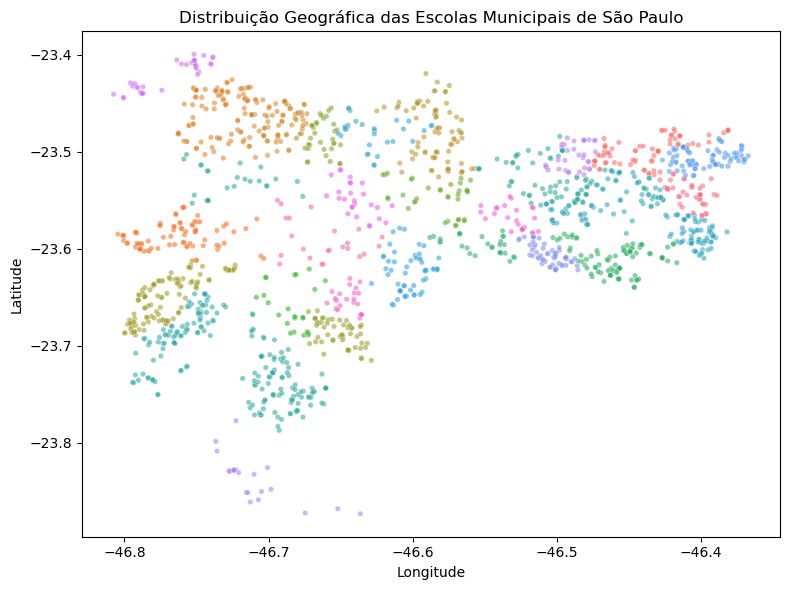

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=escolas, x='longitude', y='latitude', hue='subprefeitura', alpha=0.6, s=15, legend=False)
plt.title('Distribuição Geográfica das Escolas Municipais de São Paulo')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()